<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_spleen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-Spleen.h5ad")
print(list(adata_aging.obs.columns))

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden']


/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
B cell                             2851
CD4-positive, alpha-beta T cell     414
CD8-positive, alpha-beta T cell     354
proerythroblast                     107
NK cell                              87
Name: count, dtype: int64


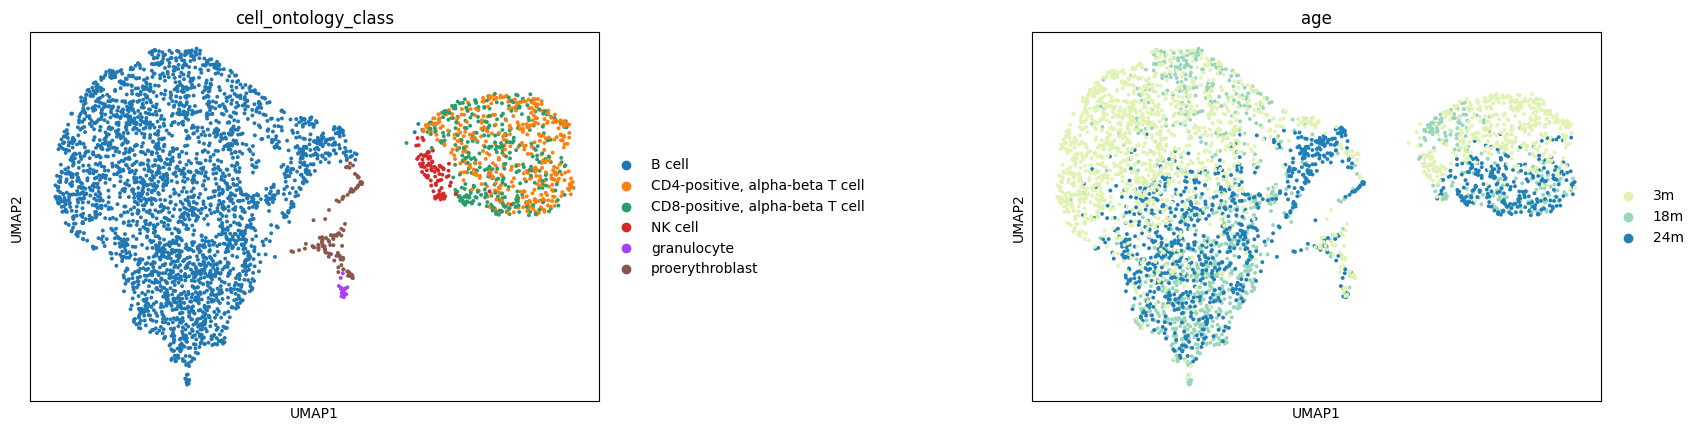

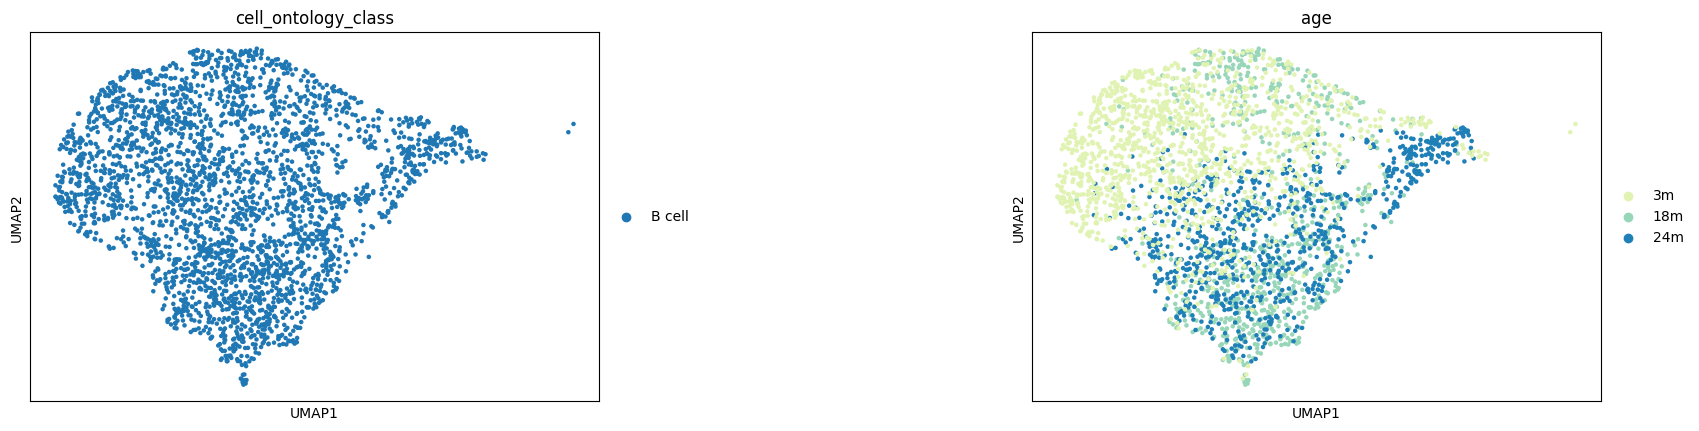

In [12]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
B_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'B cell'].copy()
sc.pl.umap(B_cells, color=['cell_ontology_class', 'age'], wspace=0.6)

Top Aging B cell Genes (p < 0.05):
     18m_n     18m_l          18m_p
0   Tmsb10  2.948224  9.636958e-289
1     Cfl1  1.922906  4.033167e-202
2   Rpl13a  1.596439  5.371354e-178
3    Cd79a  0.597804  1.232034e-142
5     Pfn1  1.344650  7.265540e-109
6   Tmsb4x  1.089383   1.570963e-97
7    Rpl13  1.124686   2.467367e-86
8      B2m  1.118673   3.338243e-82
9      Ltb  1.098416   7.782949e-57
10   Rpl35  1.072729   3.146783e-56
11    Jund  1.680943   8.725911e-50
12    Fth1  0.821220   3.028189e-49
13    Ptma  1.017503   5.409823e-49
14   H2-D1  0.799927   9.225611e-46
15   Cotl1  1.285347   2.746940e-43
16     Ubb  0.919023   3.638765e-43
17    Rps7  0.884923   8.274110e-43
18     Fau  0.864526   1.311416e-42
20    Cyba  0.922739   6.336727e-39
21   Rpl36  0.803335   6.344887e-38


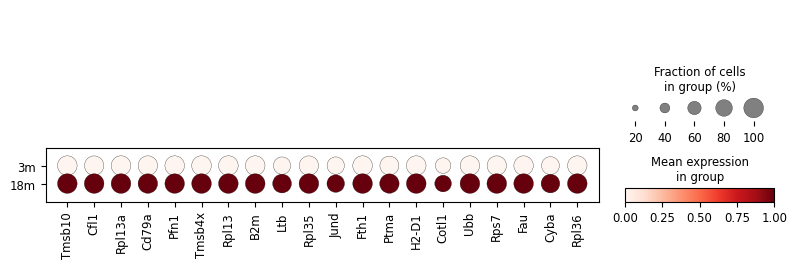

Top Downregulated B cell Genes (p < 0.05):
         18m_n     18m_l         18m_p
22965    Lars2 -1.865545  9.755916e-66
22964  Serinc3 -1.755798  1.614373e-61
22962   Map3k1 -1.672802  1.754261e-35
22961     Eef2 -0.979308  2.995631e-31
22960      Trf -2.790106  3.427813e-30
22959    Serp1 -0.800769  1.795946e-24
22957     Plp1 -4.119914  1.582607e-22
22956     Myh9 -0.690562  3.157622e-22
22955    Sparc -0.911086  3.432008e-22
22954     Lyz2 -3.147640  2.614172e-21
22953  Zfp36l2 -1.425595  1.117529e-20
22952    Actr3 -0.734957  1.239253e-19
22951      Ubc -0.868760  8.907238e-18
22950     Krt8 -3.685878  1.348938e-16
22949     Ddx5 -0.809398  3.813212e-16
22948     Ets1 -0.799909  1.887537e-15
22947     Lcp1 -0.739661  3.477701e-15
22946    Txnip -1.234362  1.522977e-13
22944   Lrrc58 -1.151695  8.300296e-13
22943      Lyn -0.982520  1.203272e-10


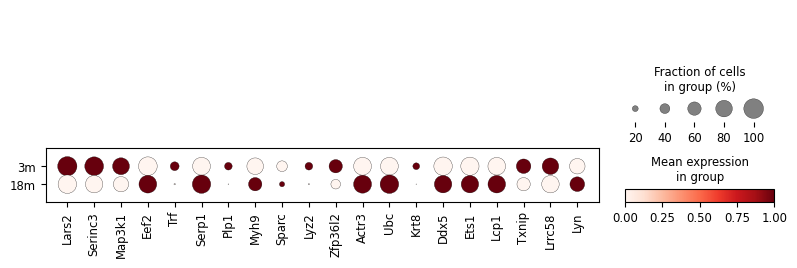

In [15]:
import pandas as pd
sc.tl.rank_genes_groups(
    B_cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon',
    use_raw=False
)
result = B_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.5) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 0.05].sort_values(by='18m_p', ascending=True)
print("Top Aging B cell Genes (p < 0.05):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset = B_cells[B_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_genes,
    groupby='age',
    standard_scale='var'
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < -0.5) &
    (dataframe['18m_l'] > -15) &
    (dataframe['18m_l'] != float('-inf'))
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 0.05].sort_values(by='18m_p', ascending=True)
print("Top Downregulated B cell Genes (p < 0.05):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset = B_cells[B_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var'
)